<h1 style="color:red;font-weight:bold;text-align:center;font-size:35px;">Telco customer churn Analysis</h1>

In [2]:
import pandas as pd 
import numpy as np 
# from sklearn.model_selection import Pipeline
import matplotlib.pyplot as plt 

telco = pd.read_csv("Telco_customer_churn.csv")

<p style="font-size:20px; color:orange;">
    In this dataset, we will analyze the Telco Customer Churn dataset, which shows different attributes along with churn value, churn score, and churn label. Among these, churn value is our target, which needs to be predicted using other input attributes.<br>
    Churn = the number of customers who end their relationship with a company within a given period.<br>
             In which churn value 1 means already leaving 0 means still active.
    <br>Also, in this dataset, some columns are not required. We also remove them. First, we analyze all columns and find out which are important and which are not.<br>
    <br>
</p>
<p style="font-size:20px; color:DodgerBlue;">
Also here we indicate different comments in different colors<br>
    Start and exit = orange<br>
    Important points = yellow<br>
    Task to do = Green <br>
    Ans of GPT = pink

    
    
</p>
 
 
 
 
 


In [3]:
telco.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [4]:
telco.shape

(7043, 33)

In [5]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
telco.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [7]:
telco['Total Charges'].dtype


dtype('O')

In [8]:
telco['Total Charges'].head(10)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object

In [9]:
telco.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [10]:
telco.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

In [11]:
telco['Streaming TV'].head(10)

0                     No
1                     No
2                    Yes
3                    Yes
4                    Yes
5                     No
6                     No
7    No internet service
8                    Yes
9                     No
Name: Streaming TV, dtype: object

<p style = "font-size:20px; color:orange;">
    On day 1, I learn to analyze the dataset by examining column types, checking for null values, identifying columns that are not in proper format, determining which columns are useless and need to be dropped, and assessing which columns are interrelated. This dataset has 32 columns, which need to be split into multiple groups for insights, ML, and the target. 
</p>

<p style ="color:orange; font-size:20px">
    Now, it's Day 2 of solving a real-world project with GPT.
    Yesterday, I learn about loading and perform some basic actions on it. Now today I will do some cleaning, group-specific columns and perform operation separately.<br>
    Today work:<br>
List of dropped columns + reason<br>
Confirmation Total Charges is numeric<br>
Class imbalance result<br>
Final column list (clean dataset shape)<br>
Grouping Columns
</p>

In [12]:
telco.head(10)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
5,4190-MFLUW,1,United States,California,Los Angeles,90020,"34.066367, -118.309868",34.066367,-118.309868,Female,...,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes,1,78,5925,Competitor offered higher download speeds
6,8779-QRDMV,1,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582,Male,...,Month-to-month,Yes,Electronic check,39.65,39.65,Yes,1,100,5433,Competitor offered more data
7,1066-JKSGK,1,United States,California,Los Angeles,90024,"34.066303, -118.435479",34.066303,-118.435479,Male,...,Month-to-month,No,Mailed check,20.15,20.15,Yes,1,92,4832,Competitor made better offer
8,6467-CHFZW,1,United States,California,Los Angeles,90028,"34.099869, -118.326843",34.099869,-118.326843,Male,...,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes,1,77,5789,Competitor had better devices
9,8665-UTDHZ,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Month-to-month,No,Electronic check,30.20,30.2,Yes,1,97,2915,Competitor had better devices


<div style ="font-size:15px; color:yellow;">
     The columns that are useless and need to be dropped are <br>
    CustomerID<br>
Count<br>
Country<br>
State<br>
City<br>
Zip Code<br>
Lat Long<br>
Latitude<br>
Longitude<br>
Churn Label<br>
Churn Score<br>
Churn Reason<br>
CLTV (temporarily)

</div>



In [13]:
telco.drop(["CustomerID","Count","Country","State","City","Zip Code","Lat Long","Latitude","Longitude","Churn Label","Churn Score","Churn Reason"], axis=1, inplace=True)


In [14]:
telco

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,0,5306
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,0,2140
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,0,5560
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,2793


In [15]:
telco[telco["Total Charges"] == " "]



,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,0,2578
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,0,5504
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,,0,2048
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,0,4950
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,0,4740
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,0,2019
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,0,2299
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,0,3763
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,0,4890
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,,0,2342


In [16]:
telco["Total Charges"] = telco["Total Charges"].str.strip()
telco.loc[telco["Total Charges"] == "", "Total Charges"] = np.nan

telco["Total Charges"] = telco["Total Charges"].replace(r"^\s*$", np.nan, regex=True)


In [17]:
telco.loc[telco["Total Charges"].isnull()]

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
2234,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0,2578
2438,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0,5504
2568,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0,2048
2667,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0,4950
2856,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0,4740
4331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0,2019
4687,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0,2299
5104,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0,3763
5719,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0,4890
6772,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0,2342


In [18]:
telco.dropna(inplace=True)

In [19]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   object 
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   object 
 16  Payment Method     7032 non-n

In [20]:
telco["Total Charges"] = telco["Total Charges"].astype(float)


In [21]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7032 non-null   object 
 1   Senior Citizen     7032 non-null   object 
 2   Partner            7032 non-null   object 
 3   Dependents         7032 non-null   object 
 4   Tenure Months      7032 non-null   int64  
 5   Phone Service      7032 non-null   object 
 6   Multiple Lines     7032 non-null   object 
 7   Internet Service   7032 non-null   object 
 8   Online Security    7032 non-null   object 
 9   Online Backup      7032 non-null   object 
 10  Device Protection  7032 non-null   object 
 11  Tech Support       7032 non-null   object 
 12  Streaming TV       7032 non-null   object 
 13  Streaming Movies   7032 non-null   object 
 14  Contract           7032 non-null   object 
 15  Paperless Billing  7032 non-null   object 
 16  Payment Method     7032 non-n

In [22]:
telco['Churn Value'].value_counts(normalize=True)

Churn Value
0    0.734215
1    0.265785
Name: proportion, dtype: float64

<p style="font-size:20px; color:pink;">
Here is the most important thing to understand before going forward. The previous step, I do is to know about the distribution of data in two categories because, as it is a regression question and churn has only two values, yes or no, so how many churners and how many are not is determined using this. Here in output we get 0 = 0.734215 and 1= 0.265785, which shows almost 73% didnt churn and left 23% are churners. It shows how imbalanced the class is. Here, the class is imbalanced, but it is still manageable. This imbalance shows high accuracy in all predictions, although it is not so we kept the accuracy side and checked other performance metrics to evaluate.
</p>

In [23]:

vis = ["Gender","Senior Citizen","Partner","Dependents"]
serv= ["Phone Service","Multiple Lines","Internet Service","Online Security","Online Backup","Device Protection","Tech Support","Streaming TV","Streaming Movies"]
bill = ["Tenure Months","Contract","Paperless Billing","Payment Method","Monthly Charges","Total Charges"]
target=["Churn Value"]

feature_groups = {
    "Customer Info": vis,
    "Services": serv,
    "Billing": bill,
    "Target": target
}

In [24]:
telco.groupby("Gender")["Churn Value"].mean()

Gender
Female    0.269595
Male      0.262046
Name: Churn Value, dtype: float64

<p style="font-size:20px; color:orange;">
From there I complete my Day 2 tasks and now its time for Day 3 tomorrow.
</p>

<p style="font-size:20px; color:orange;">
Now its time for day 3 and today i will analyze the dataset properly by comparing different input variables with churn and find out "Who churns more and why?" 
</p>

In [25]:
telco["Churn Value"].value_counts()

Churn Value
0    5163
1    1869
Name: count, dtype: int64

In [26]:

telco["Churn Value"].mean()

np.float64(0.26578498293515357)

<p style="font-size:20px; color:pink;">
From this we found that 1869 people are already leaving the services that is  around 26.57% already churns and remaining are all active. i think its also a big percentage the company should do something to stop it and found out where the company lacks so that people are leaving their services.<br>
Business is at little risk if certain actions are not taken properly they can lose more.
</p>

In [27]:
telco.groupby("Churn Value")["Tenure Months"].describe()


,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [28]:
telco[telco["Churn Value"] == 1]

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,Male,No,No,No,12,Yes,No,DSL,No,No,...,Yes,Yes,No,One year,Yes,Electronic check,59.80,727.80,1,4581
1865,Female,No,No,No,9,Yes,No,DSL,No,No,...,No,No,No,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,1,2029
1866,Male,Yes,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,75.75,75.75,1,5571
1867,Female,No,No,No,67,Yes,Yes,Fiber optic,Yes,Yes,...,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,1,5620


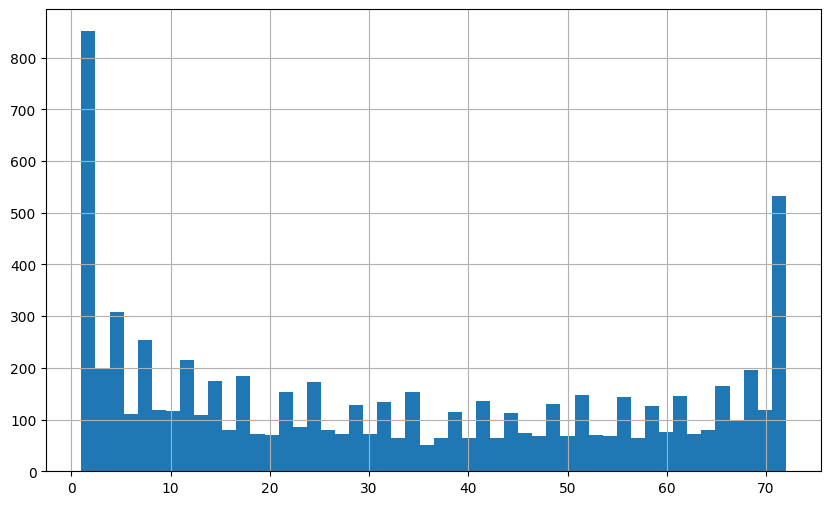

In [29]:
telco["Tenure Months"].hist(bins=50, figsize=(10, 6))
plt.show()


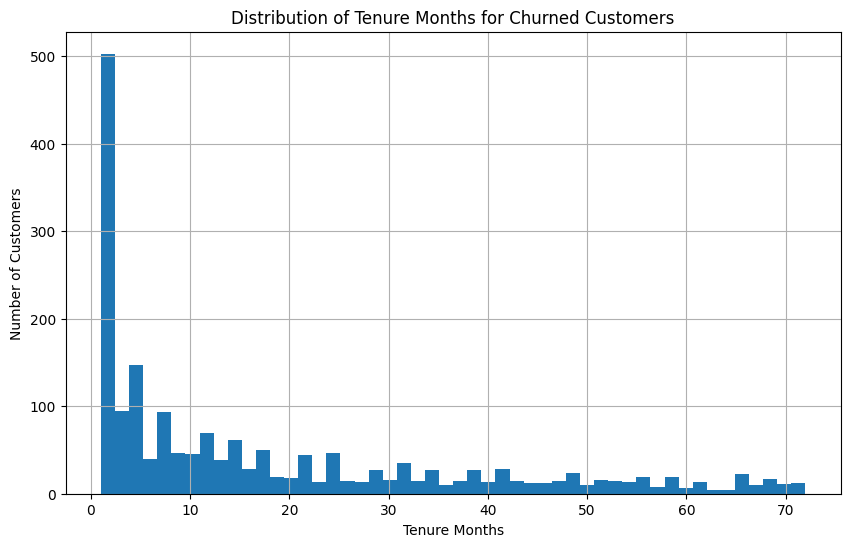

In [30]:
churned_tenure = telco[telco["Churn Value"] == 1]["Tenure Months"]
plt.figure(figsize=(10, 6))
churned_tenure.hist(bins=50) 
plt.title("Distribution of Tenure Months for Churned Customers")
plt.xlabel("Tenure Months")
plt.ylabel("Number of Customers")
plt.show()
                    


<p style="font-size:20px; color:pink;">
This histogram shows that the people having very low tenure months (1,2,3) churns more than others. As it is obvious people who are using less the services are leaving fast. so if the customers comes and get subscription of only 1,2 or 3 months are more likely to churn so we need to focus on them by giving them proper services. 
</p>

In [31]:
telco.groupby("Churn Value")["Monthly Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


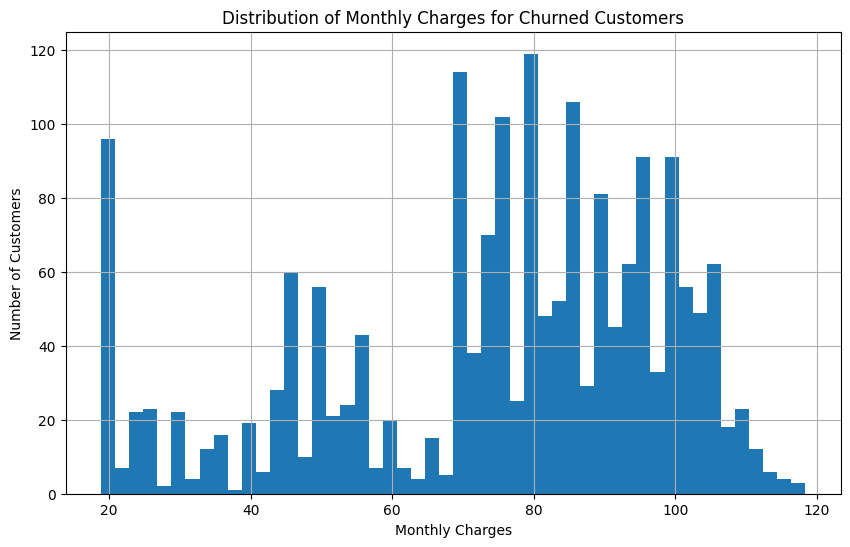

In [32]:
churned_mont = telco[telco["Churn Value"] == 1]["Monthly Charges"]
plt.figure(figsize=(10, 6))
churned_mont.hist(bins=50) 
plt.title("Distribution of Monthly Charges for Churned Customers")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

<p style="font-size:20px; color:pink;">
The monthly charges paid by churners are scatter as there is no clear way to say because the distribution doesnt so clear difference as the customers who pays less are also churned and who pays high are also churned so we cannot get proper insight from monthly charges.
</p>

In [33]:
telco.groupby("Churn Value")["Total Charges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
1,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


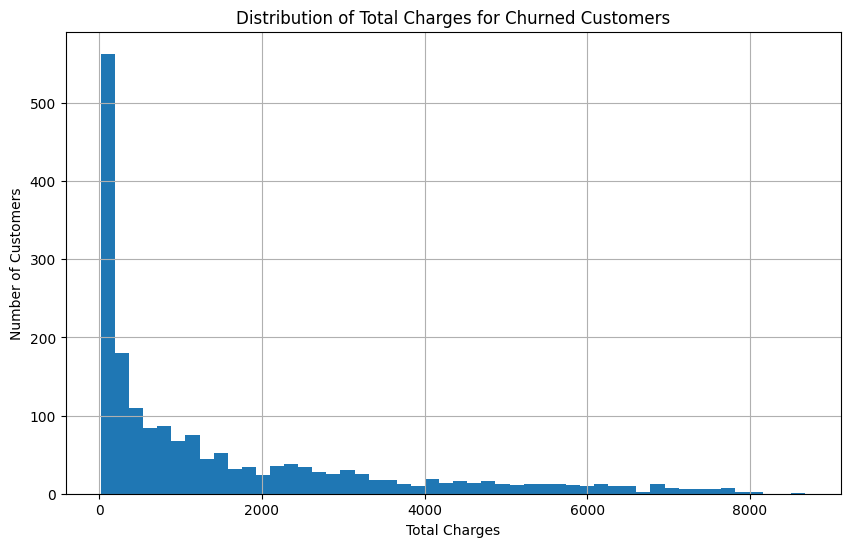

In [34]:
churned_tot = telco[telco["Churn Value"] == 1]["Total Charges"]
plt.figure(figsize=(10, 6))
churned_tot.hist(bins=50) 
plt.title("Distribution of Total Charges for Churned Customers")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

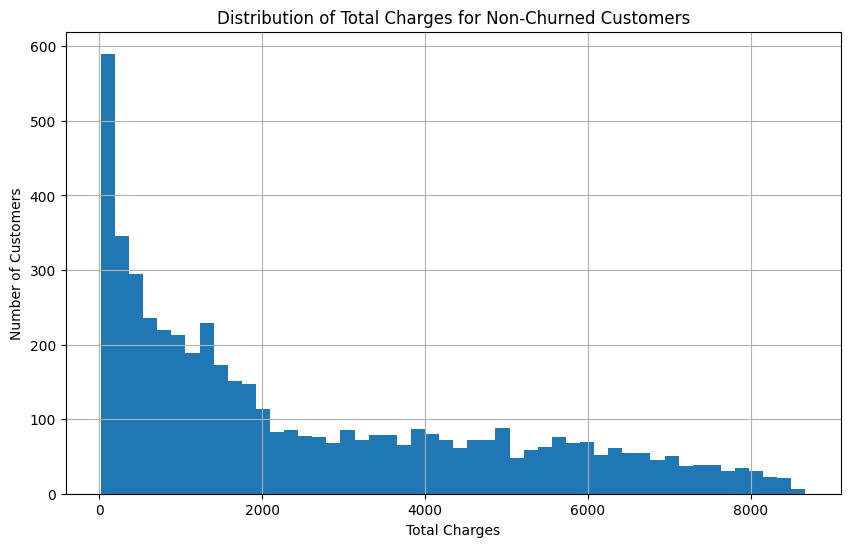

In [35]:
nonchurned_tot = telco[telco["Churn Value"] == 0]["Total Charges"]
plt.figure(figsize=(10, 6))
nonchurned_tot.hist(bins=50) 
plt.title("Distribution of Total Charges for Non-Churned Customers")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")
plt.show()

<p style="font-size:20px; color:pink;">
    The total charges paid by both churned and non churned customers are almost similar from 0-1500 then it varies little less the charges decreases for churned which is obvious because they are leaving so total charges decreases also non churned customers total charges also decreases.<br>
I think total charges are not higher for non-churners but if we compare with churned customers they are high.
</p>


In [36]:
telco.groupby("Contract")["Churn Value"].mean()


Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn Value, dtype: float64

In [37]:
telco.groupby("Payment Method")["Churn Value"].mean()

Payment Method
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Electronic check             0.452854
Mailed check                 0.192020
Name: Churn Value, dtype: float64

In [38]:
telco.groupby("Internet Service")["Churn Value"].mean()

Internet Service
DSL            0.189983
Fiber optic    0.418928
No             0.074342
Name: Churn Value, dtype: float64

In [39]:
telco.groupby("Tech Support")["Churn Value"].mean()

Tech Support
No                     0.416475
No internet service    0.074342
Yes                    0.151961
Name: Churn Value, dtype: float64

In [40]:
telco.groupby("Online Security")["Churn Value"].mean()

Online Security
No                     0.417787
No internet service    0.074342
Yes                    0.146402
Name: Churn Value, dtype: float64

In [41]:
telco.groupby("Partner")["Churn Value"].mean()

Partner
No     0.329761
Yes    0.197171
Name: Churn Value, dtype: float64

In [42]:
telco.groupby("Senior Citizen")["Churn Value"].mean()

Senior Citizen
No     0.236503
Yes    0.416813
Name: Churn Value, dtype: float64

<p style="font-size:20px; color:pink;">
    By comparing different categorical attributes with churn value we get 

Contract = 42% of the customers who paid month-to month are churned as compared to one year(11%) which is more less if contract              is two year(2%)<br>

Internet service= The customers having fiber optics are churned more 41% than who use DSL 18% which is more less if they dont have internet services.(7%)<br>

Payment method= The customer who pays using electronic check are churned more 45% than other payments method whic are in range of 15-20%<br>

Tech support = The customers who dont have tech support are churned more 41% than having tech support 15% and people who dont have internet service are less(7%) as it also clear in internet sevice columns also<br>

Online security = as it is also related with internet service so people having no internet service are churned lesss(7%) and                       then if they have but dont have online security are churned more(41%) than having online security(14%)<br>

Partner = the people having partner are churned less(19%) than who dont have(32%) i think this cannot give proper analysis<br>

Senior citizen=  the senior citizen people are churned more(41%) than the young ones (23%)   <br>
<br>
After all comparisions we found that the less contract people with good internet service and senior citizens are churned more and also people pay with electronic checks , having less tech support and security are also churned more.



</p>

In [43]:
telco

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0,5306
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,2140
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,5560
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,2793


<p style ="color:orange; font-size:20px">
     Now Today is Day 4 and now we are doing "MULTIVARIATE ANALYSIS".
Today we check interactions between different input variables which in result cause the churn. as churn is not occur only by one factor.
</p>



In [44]:
telco["Tenure Group"] = pd.cut(
    telco["Tenure Months"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "12-24", "24-48", "48+"]
)

In [45]:
telco["Tenure Group"].value_counts()

Tenure Group
48+      2239
0-12     2175
24-48    1594
12-24    1024
Name: count, dtype: int64

In [47]:
telco.groupby(["Contract", "Tenure Group"])["Churn Value"].mean().unstack()

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_74125/3527107724.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  telco.groupby(["Contract", "Tenure Group"])["Churn Value"].mean().unstack()


Tenure Group,0-12,12-24,24-48,48+
Contract,,,,
Month-to-month,0.513541,0.377205,0.329177,0.260234
One year,0.105691,0.081218,0.106178,0.129338
Two year,0.000000,0.000000,0.021898,0.033254
